In [2]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [3]:
card_df = pd.read_csv("card_features.csv")
fix_map = {
    0: 0,  # ansei
    1: 2,  # rajhin
    2: 5,  # hlaalu
    3: 6,  # pelin
    4: 7,  # red eagle
    5: 4,  # psijic
    6: 1,  # crows
    7: 3,  # orgnum
    8: 8,  # treasury
    9: 9,  # saint alessia
}
card_df["deck_id"] = card_df["deck_id"].map(fix_map)

tensor_idx_to_card_id = card_df["id"].tolist()
X_raw = card_df.drop(columns=["id", "deck_id"])

In [4]:
with open("cards.json", "r", encoding="utf-8") as f:
    cards_metadata = json.load(f)

In [15]:
id_to_name = {card["id"]: card["Name"] for card in cards_metadata}
deck_id_to_name = {
    0: "Ansei", 1: "Duke of Crows", 2: "Rajhin", 3: "Orgnum", 4: "Psijic",
    5: "Hlaalu", 6: "Pelin", 7: "Red Eagle", 8: "Treasury", 9: "Saint Alessia"
}

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

In [7]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

In [8]:
class CardAutoEncoder(nn.Module):
    def __init__(self, input_dim=56, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

In [9]:
model = CardAutoEncoder(input_dim=X_tensor.shape[1], latent_dim=64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

n_epochs = 500
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    x_rec, z = model(X_tensor)
    loss = loss_fn(x_rec, X_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 1.0018
Epoch 50: Loss = 0.2447
Epoch 100: Loss = 0.0330
Epoch 150: Loss = 0.0092
Epoch 200: Loss = 0.0051
Epoch 250: Loss = 0.0026
Epoch 300: Loss = 0.0017
Epoch 350: Loss = 0.0021
Epoch 400: Loss = 0.0011
Epoch 450: Loss = 0.0008


In [10]:
model.eval()
with torch.no_grad():
    _, embeddings = model(X_tensor)

emb_np = embeddings.numpy()

In [11]:
card_ids = card_df["id"].values.astype(int)
deck_ids = card_df["deck_id"].values

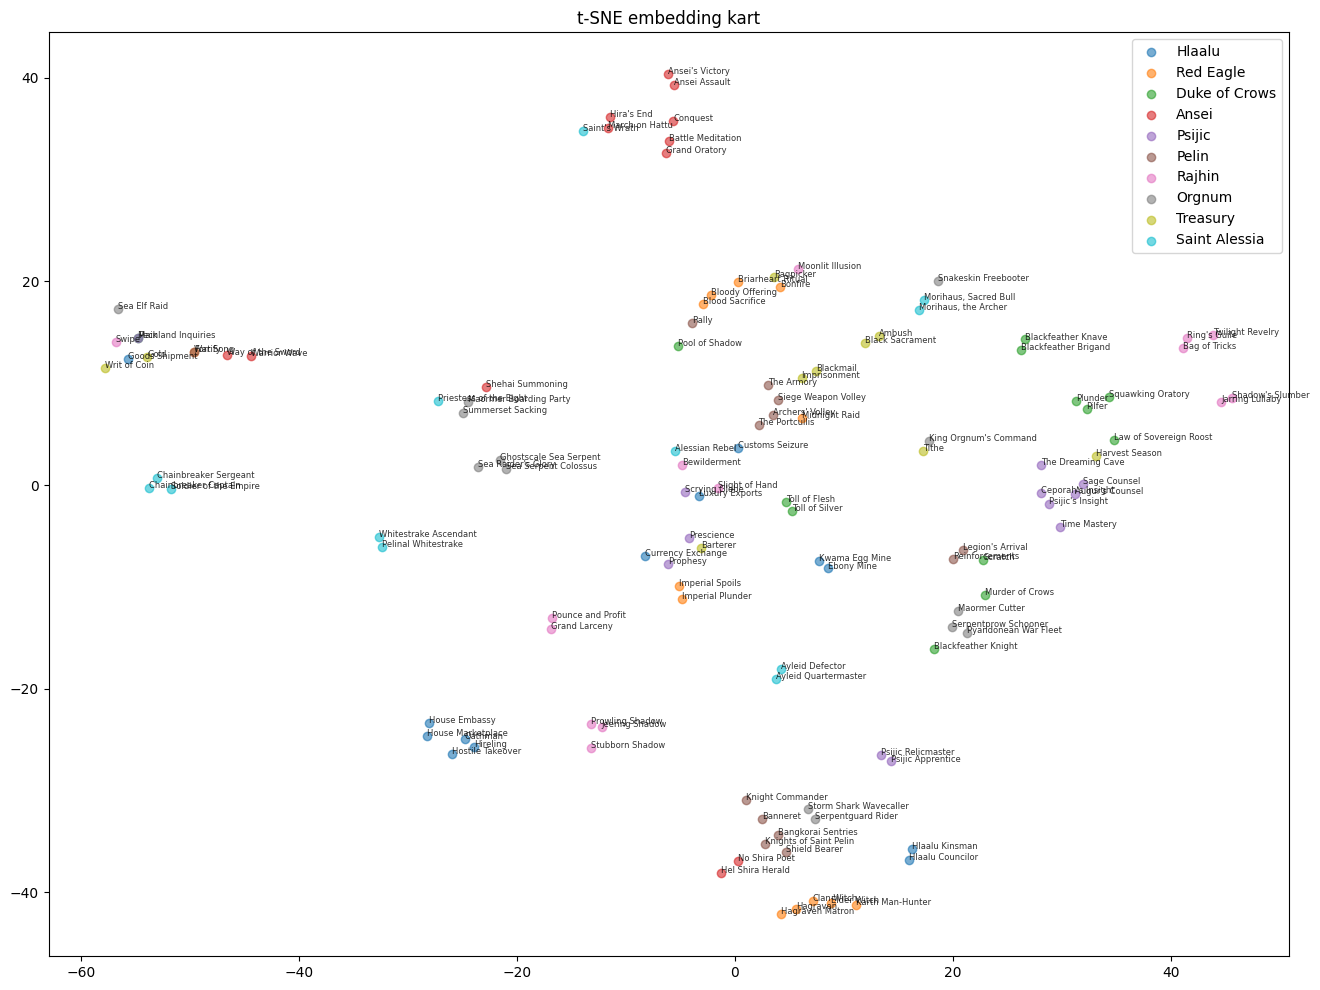

In [ ]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
emb_2d = tsne.fit_transform(emb_np)

df_vis = pd.DataFrame({
    "x": emb_2d[:, 0],
    "y": emb_2d[:, 1],
    "card_id": card_ids,
    "deck_id": deck_ids,
    "card_name": [id_to_name.get(cid, f"Card {cid}") for cid in card_ids],
    "deck": [deck_id_to_name.get(did, f"Deck {did}") for did in deck_ids]
})

plt.figure(figsize=(16, 12))
for deck in df_vis["deck"].unique():
    subset = df_vis[df_vis["deck"] == deck]
    plt.scatter(subset["x"], subset["y"], label=deck, alpha=0.6)

for _, row in df_vis.iterrows():
    plt.text(row["x"], row["y"], row["card_name"], fontsize=6, alpha=0.8)

plt.legend()
plt.title("t-SNE card embeddings")
plt.show()

In [17]:
torch.save(model.encoder.state_dict(), "models/card_encoder.pt")

In [18]:
with torch.no_grad():
    embeddings = model.encoder(torch.tensor(X_raw.values, dtype=torch.float32)).numpy()
np.save("models/card_embeddings.npy", embeddings)